# SFT Training Results — Visualization

This notebook reads the simplified CSV and generates the two graphs:
- Learning rate vs **Loss** & **Overall grammar accuracy** (with base-model reference line)
- Learning rate vs **JSON/YAML/XML/TOML/CSV** accuracies (with base-model reference lines)

Both figures:
- Fix accuracy range to **0–100**
- Fix loss range to **0.00–3.00**
- Add an inset zoom for **90–100%** to see small differences clearly

The generated PNG files are also displayed in this notebook.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from IPython.display import Image, display
import os

# === Input CSV (update if needed) ===
CSV_PATH = 'LLM2025_Autom_result_r1alpha2.csv'
CSV_PATH = 'LLM2025_Autom_result.csv'

if not os.path.exists(CSV_PATH):
    # Fallback for environments where the file is mounted elsewhere
    alt = os.path.join('/mnt/data', os.path.basename(CSV_PATH))
    if os.path.exists(alt):
        CSV_PATH = alt


# === Output PNG filenames ===
OUT_PNG_1 = 'sft_simple_lr_loss_overall_fixed_ranges_with_zoom.png'
OUT_PNG_2 = 'sft_simple_lr_formats_fixed_ranges_with_zoom.png'

# === Known correction (only applied if such row exists) ===
FIX_JSON43 = True

# === VIVID COLORS (metric base colors) ===
VIVID = {
    'loss':   '#00AEEF',  # cyan
    'overall':'#5856D6',  # indigo
    'JSON':   '#FF9500',  # orange
    'YAML':   '#34C759',  # green
    'XML':    '#AF52DE',  # purple
    'TOML':   '#00C7BE',  # teal
    'CSV':    '#FFD60A',  # vivid yellow
}
RED_EDGE = '#FF0000'  # repetition marker edge

totals = {'CSV':20, 'JSON':50, 'TOML':25, 'XML':19, 'YAML':35}
colmap = {'CSV':'csv','JSON':'json','TOML':'toml','XML':'xml','YAML':'yaml'}


In [2]:
# Load CSV
df = pd.read_csv(CSV_PATH).copy()

# Optional fix: sft_inference_43.json JSON correct count should be 50
if FIX_JSON43 and '出力ファイル名' in df.columns and 'json' in df.columns:
    df.loc[df['出力ファイル名'] == 'sft_inference_43.json', 'json'] = 50

# Rename columns
df = df.rename(columns={'全体パース率':'overall_grammar_accuracy_pct', '繰り返し':'repetition_flag'})

# Separate base model row (expected: base_model_inference.json)
base_mask = df['出力ファイル名'].astype(str).str.contains('base_model', na=False)
df_base = df[base_mask].copy()
df_sft = df[~base_mask].copy()

# Numeric coercion for SFT rows
df_sft['loss'] = pd.to_numeric(df_sft.get('loss', np.nan), errors='coerce')
df_sft['overall_grammar_accuracy_pct'] = pd.to_numeric(df_sft.get('overall_grammar_accuracy_pct', np.nan), errors='coerce')
df_sft['learning_rate'] = pd.to_numeric(df_sft.get('learning_rate', np.nan), errors='coerce')
df_sft['repetition_flag'] = pd.to_numeric(df_sft.get('repetition_flag', 0), errors='coerce').fillna(0).astype(int)

for fmt, total in totals.items():
    c = colmap[fmt]
    df_sft[c] = pd.to_numeric(df_sft.get(c, np.nan), errors='coerce')
    df_sft[f'{fmt}_correct'] = df_sft[c].fillna(0).astype(int)
    df_sft[f'{fmt}_accuracy_pct'] = df_sft[f'{fmt}_correct'] / total * 100.0

# Clean and sort
df_sft = df_sft.dropna(subset=['learning_rate']).sort_values('learning_rate').reset_index(drop=True)
x = df_sft['learning_rate'].values
rep = df_sft['repetition_flag'].values.astype(int)

# Base model values (if present)
base_overall = None
base_counts = None
base_pct = {}
if len(df_base) > 0:
    base_row = df_base.iloc[0]
    base_overall = float(pd.to_numeric(base_row.get('overall_grammar_accuracy_pct', np.nan), errors='coerce'))
    base_counts = {fmt: int(pd.to_numeric(base_row.get(colmap[fmt], np.nan), errors='coerce')) for fmt in totals}
    base_pct = {fmt: base_counts[fmt] / totals[fmt] * 100.0 for fmt in totals}

# Choose x-axis scale
use_log = (x.min() > 0) and (x.max() / x.min() >= 5)

df_sft[['learning_rate','loss','overall_grammar_accuracy_pct','repetition_flag']]


,learning_rate,loss,overall_grammar_accuracy_pct,repetition_flag
0,0.000001,2.3167,85.3,0
1,0.000010,2.1356,85.3,0
2,0.000025,1.6683,88.7,0
3,0.000045,1.3791,93.3,0
4,0.000050,1.3355,96.0,0
5,0.000053,1.3198,96.0,0
6,0.000055,1.3022,96.0,0
7,0.000060,1.2641,94.7,0
8,0.000075,1.1705,94.7,1
9,0.000100,1.0615,94.0,1


In [3]:
def add_accuracy_inset(parent_ax, x, y, color, rep, use_log, title_text=None, y0=90, y1=100):
    axins = inset_axes(
        parent_ax,
        width='42%', height='42%',
        loc='lower left',
        bbox_to_anchor=(0.05, 0.05, 0.9, 0.9),
        bbox_transform=parent_ax.transAxes,
        borderpad=0.8,
    )
    axins.plot(x, y, color=color, linewidth=2.0)
    axins.scatter(
        x, y,
        facecolors=color,
        edgecolors=np.where(rep==1, RED_EDGE, color),
        linewidths=1.8,
        s=55,
        zorder=3,
    )
    axins.set_ylim(y0, y1)
    if use_log:
        axins.set_xscale('log')
    axins.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)
    axins.tick_params(labelsize=8)
    if title_text:
        axins.set_title(title_text, fontsize=9)
    try:
        mark_inset(parent_ax, axins, loc1=2, loc2=4, fc='none', ec='0.4', lw=0.8)
    except Exception:
        pass
    return axins


In [4]:
# --- Plot 1: Loss + Overall grammar accuracy ---
fig, ax_loss = plt.subplots(figsize=(13.6,7.6))
ax_acc = ax_loss.twinx()

loss_color = VIVID['loss']
overall_color = VIVID['overall']

ax_loss.plot(x, df_sft['loss'].values, color=loss_color, linewidth=2.2, label='Loss')
ax_acc.plot(x, df_sft['overall_grammar_accuracy_pct'].values, color=overall_color, linewidth=2.2,
            label='Overall grammar accuracy (%)')

# Points: fill=metric color, edge=red if repetition
ax_loss.scatter(
    x, df_sft['loss'].values,
    facecolors=loss_color,
    edgecolors=np.where(rep==1, RED_EDGE, loss_color),
    linewidths=2.2, s=90, zorder=3,
)
ax_acc.scatter(
    x, df_sft['overall_grammar_accuracy_pct'].values,
    facecolors=overall_color,
    edgecolors=np.where(rep==1, RED_EDGE, overall_color),
    linewidths=2.2, s=90, zorder=3,
)

# Point annotations (like the format graph)
for i in range(len(df_sft)):
    ax_loss.annotate(f"{df_sft.loc[i,'loss']:.4f}", (x[i], df_sft.loc[i,'loss']),
                     textcoords='offset points', xytext=(6,6), fontsize=8)
    ax_acc.annotate(f"{df_sft.loc[i,'overall_grammar_accuracy_pct']:.1f}%", (x[i], df_sft.loc[i,'overall_grammar_accuracy_pct']),
                    textcoords='offset points', xytext=(6,6), fontsize=8)

# Base model reference line (overall)
if base_overall is not None and np.isfinite(base_overall):
    ax_acc.axhline(
        base_overall,
        linestyle='--',
        linewidth=2.2,
        color=overall_color,
        label=f"Base model: Overall grammar accuracy ({base_overall:.1f}%)",
    )

# Axis scales and fixed ranges
if use_log:
    ax_loss.set_xscale('log')
ax_loss.set_ylim(0.0, 3.0)
ax_acc.set_ylim(0.0, 100.0)

ax_loss.set_xlabel('Learning rate')
ax_loss.set_ylabel('Loss')
ax_acc.set_ylabel('Overall grammar accuracy (%)', labelpad=0)
ax_loss.set_title('SFT Training Results — Learning rate vs Loss & Overall grammar accuracy', pad=18)
ax_loss.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)

# Zoom inset for 90–100%

# Legend
h1,l1 = ax_loss.get_legend_handles_labels()
h2,l2 = ax_acc.get_legend_handles_labels()


# Inset (zoom) moved to the right side (outside the main axes)
inset_left, inset_bottom, inset_w, inset_h = 0.76, 0.22, 0.215, 0.24
axins = fig.add_axes([inset_left, inset_bottom, inset_w, inset_h])
axins.plot(x, df_sft['overall_grammar_accuracy_pct'].values, color=overall_color, linewidth=2.0)
axins.scatter(x, df_sft['overall_grammar_accuracy_pct'].values, facecolors=overall_color,
              edgecolors=np.where(rep==1, RED_EDGE, overall_color), linewidths=1.8, s=55, zorder=3)
if base_overall is not None and np.isfinite(base_overall):
    axins.axhline(base_overall, linestyle='--', linewidth=1.6, color=overall_color, alpha=0.95)
axins.set_ylim(90, 100)
if use_log:
    axins.set_xscale('log')
axins.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)
axins.tick_params(labelsize=8)
axins.set_title('Zoom: 90–100%', fontsize=9)

# Optional extra zoom: 90–100% AND learning_rate in [1e-5, 1e-4]
band_mask = (x >= 1e-5) & (x <= 1e-4)
if int(band_mask.sum()) > 1:
    # Use log10(x) on a linear axis for equal spacing, with tick labels as learning_rate
    x_log = np.log10(x)
    axins2 = fig.add_axes([inset_left, inset_bottom + inset_h + 0.1, inset_w, 0.24])
    axins2.plot(x, df_sft['overall_grammar_accuracy_pct'].values, color=overall_color, linewidth=2.0)
    axins2.scatter(
        x, df_sft['overall_grammar_accuracy_pct'].values,
        facecolors=overall_color,
        edgecolors=np.where(rep==1, RED_EDGE, overall_color),
        linewidths=1.6,
        s=45,
        zorder=3,
    )
    if base_overall is not None and np.isfinite(base_overall):
        axins2.axhline(base_overall, linestyle='--', linewidth=1.4, color=overall_color, alpha=0.95)
    axins2.set_ylim(90, 100)
    axins2.set_xlim(1e-5, 1e-4)
    # Linear spacing: true midpoint is the arithmetic mean
    mid_lr = (1e-5 + 1e-4) / 2
    axins2.set_xticks([1e-5, mid_lr, 1e-4])
    axins2.set_xticklabels([f"{1e-5:.2E}", f"{mid_lr:.2E}", f"{1e-4:.2E}"], rotation=0)
    band_lrs = np.unique(x[band_mask])
    # If too many learning rates in the band, show at most 4 tick labels to avoid overlap
    axins2.grid(True, which='both', linestyle='--', linewidth=0.35, alpha=0.5)
    axins2.tick_params(labelsize=8)
    axins2.set_title('Zoom: 90–100% & 1e-5–1e-4', fontsize=9)


# Legend moved below the plot (outside)
h1,l1 = ax_loss.get_legend_handles_labels()
h2,l2 = ax_acc.get_legend_handles_labels()
fig.legend(h1+h2, l1+l2, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=1, fontsize=9, frameon=True)
# Leave space for legend (bottom) and inset (right)
fig.subplots_adjust(left=0.0465, right=0.685, top=0.90, bottom=0.22)
fig.savefig(OUT_PNG_1, dpi=240)
plt.close(fig)
print('Saved:', OUT_PNG_1)


Saved: sft_simple_lr_loss_overall_fixed_ranges_with_zoom.png


In [5]:
# --- Plot 2: JSON/YAML/XML/TOML/CSV accuracies ---
fig, ax = plt.subplots(figsize=(13.6,7.6))
fmt_order = ['JSON','YAML','XML','TOML','CSV']

for fmt in fmt_order:
    y = df_sft[f'{fmt}_accuracy_pct'].values
    c = VIVID[fmt]
    ax.plot(x, y, color=c, linewidth=2.2, label=f'{fmt} accuracy (%)')
    ax.scatter(
        x, y,
        facecolors=c,
        edgecolors=np.where(rep==1, RED_EDGE, c),
        linewidths=2.2,
        s=90,
        zorder=3,
    )

    # Base model reference line per format
    if fmt in base_pct:
        ax.axhline(
            base_pct[fmt],
            linestyle='--',
            linewidth=2.0,
            color=c,
            alpha=0.95,
            label=f"Base model: {fmt} ({base_counts[fmt]}/{totals[fmt]} = {base_pct[fmt]:.1f}%)",
        )

    # Point annotations (n/total and %)
    for i in range(len(df_sft)):
        n = int(df_sft.loc[i, f'{fmt}_correct'])
        total = totals[fmt]
        pct = df_sft.loc[i, f'{fmt}_accuracy_pct']
        # Avoid overlapping the title when points are near 100%
        xytext = (6, -18) if float(pct) >= 97 else (6, 6)
        ax.annotate(
            f"{n}/{total}\n{pct:.1f}%",
            (x[i], y[i]),
            textcoords='offset points',
            xytext=xytext,
            fontsize=7,
        )

if use_log:
    ax.set_xscale('log')

# Fixed accuracy range
ax.set_ylim(0.0, 100.0)

ax.set_xlabel('Learning rate')
ax.set_ylabel('Accuracy (%)')
ax.set_title('SFT Training Results — Learning rate vs JSON/YAML/XML/TOML/CSV accuracy (with base model references)', pad=16)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)

# Inset (zoom) moved to the right side (outside the main axes)
inset2_left, inset2_bottom, inset2_w, inset2_h = 0.73, 0.22, 0.25, 0.24
axins = fig.add_axes([inset2_left, inset2_bottom, inset2_w, inset2_h])
for fmt in fmt_order:
    y = df_sft[f'{fmt}_accuracy_pct'].values
    c = VIVID[fmt]
    axins.plot(x, y, color=c, linewidth=2.0)
    axins.scatter(
        x, y,
        facecolors=c,
        edgecolors=np.where(rep==1, RED_EDGE, c),
        linewidths=1.8,
        s=55,
        zorder=3,
    )
    if fmt in base_pct:
        axins.axhline(base_pct[fmt], linestyle='--', linewidth=1.6, color=c, alpha=0.95)
axins.set_ylim(90, 100)
if use_log:
    axins.set_xscale('log')
axins.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)
axins.tick_params(labelsize=8)
axins.set_title('Zoom: 90–100%', fontsize=9)

# Optional extra zoom: 90–100% AND learning_rate in [1e-5, 1e-4]
band_mask = (x >= 1e-5) & (x <= 1e-4)
if int(band_mask.sum()) > 1:
    # Use log10(x) on a linear axis for equal spacing, with tick labels as learning_rate
    x_log = np.log10(x)
    axins2 = fig.add_axes([inset2_left, inset2_bottom + inset2_h + 0.10, inset2_w, inset2_h])
    for fmt in fmt_order:
        y = df_sft[f'{fmt}_accuracy_pct'].values
        c = VIVID[fmt]
        axins2.plot(x, y, color=c, linewidth=2.0)
        axins2.scatter(
            x, y,
            facecolors=c,
            edgecolors=np.where(rep==1, RED_EDGE, c),
            linewidths=1.6,
            s=45,
            zorder=3,
        )
        if fmt in base_pct:
            axins2.axhline(base_pct[fmt], linestyle='--', linewidth=1.4, color=c, alpha=0.95)
    axins2.set_ylim(90, 100)
    axins2.set_xlim(1e-5, 1e-4)
    # Linear spacing: true midpoint is the arithmetic mean
    mid_lr = (1e-5 + 1e-4) / 2
    axins2.set_xticks([1e-5, mid_lr, 1e-4])
    axins2.set_xticklabels([f"{1e-5:.2E}", f"{mid_lr:.2E}", f"{1e-4:.2E}"], rotation=0)
    band_lrs = np.unique(x[band_mask])
    # If too many learning rates in the band, show at most 4 tick labels to avoid overlap
    axins2.grid(True, which='both', linestyle='--', linewidth=0.35, alpha=0.5)
    axins2.tick_params(labelsize=8)
    axins2.set_title('Zoom: 90–100% & 1e-5–1e-4', fontsize=9)


# Legend moved below the plot (outside) — ONLY line descriptions
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=8, frameon=True)

# Leave space for legend (bottom) and inset (right)
fig.subplots_adjust(left=0.08, right=0.70, top=0.90, bottom=0.22)

fig.savefig(OUT_PNG_2, dpi=240, bbox_inches='tight')
plt.close(fig)
print('Saved:', OUT_PNG_2)


Saved: sft_simple_lr_formats_fixed_ranges_with_zoom.png


## Preview saved PNG files


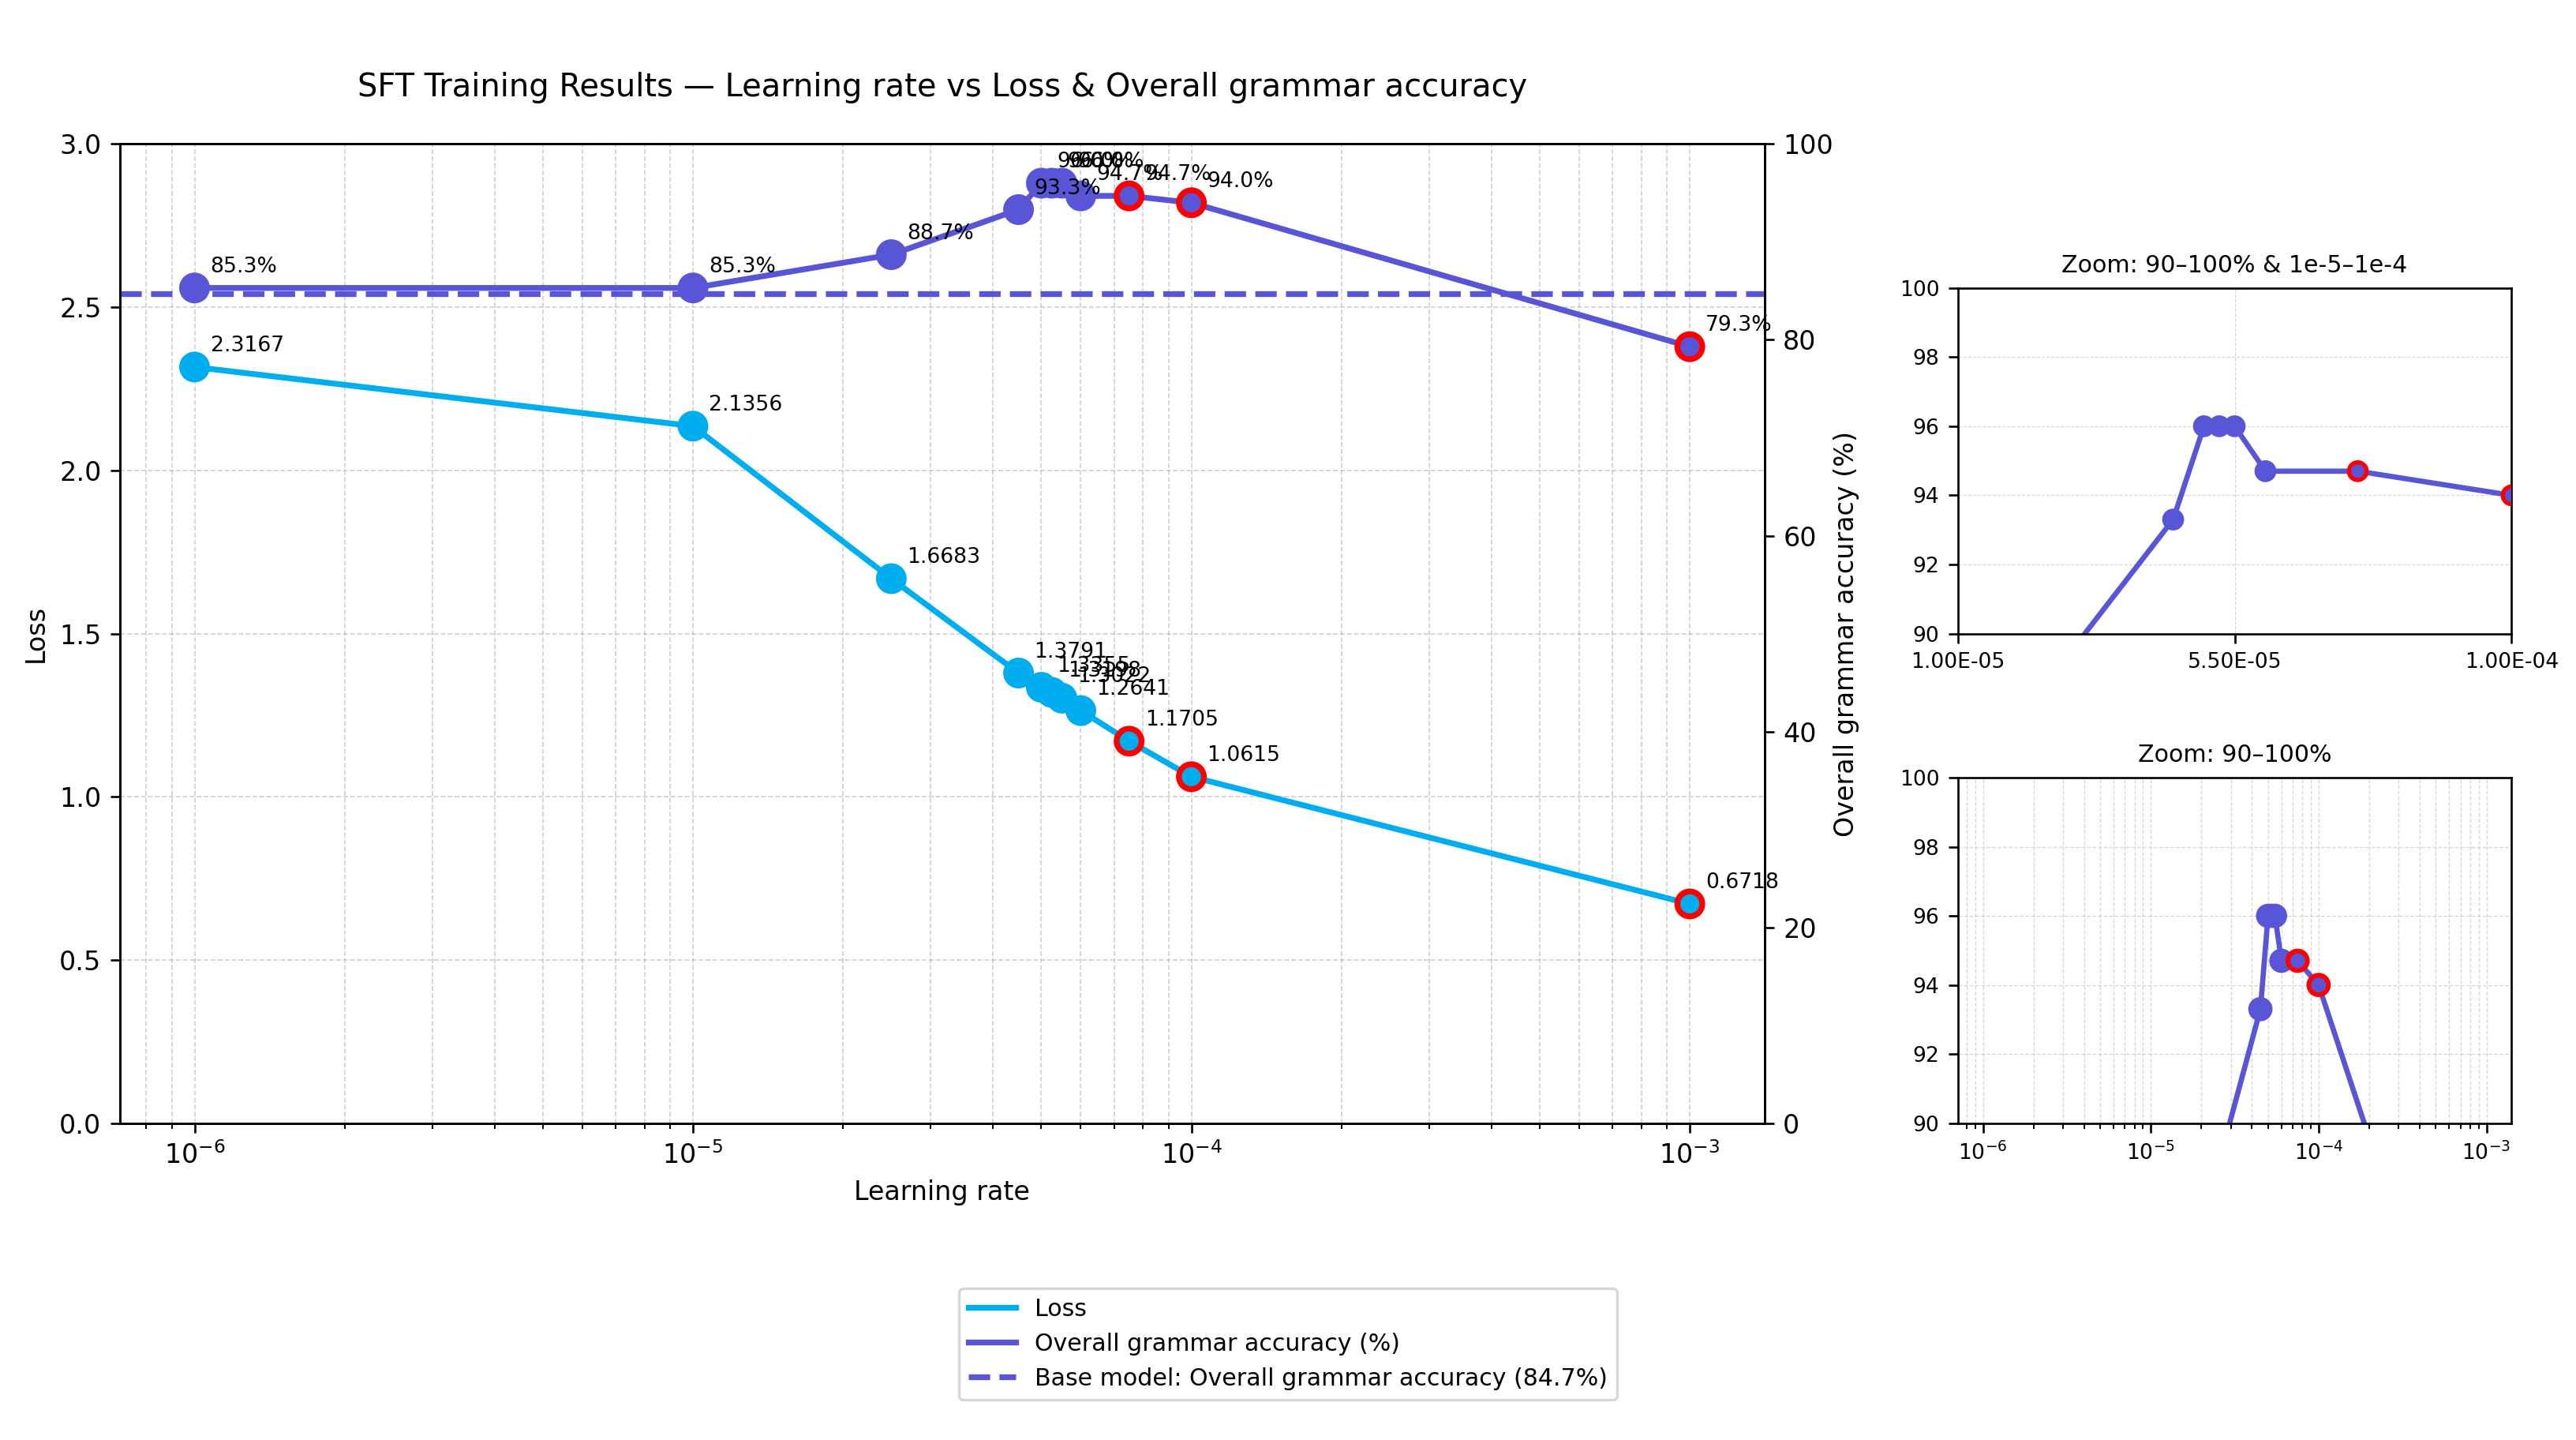

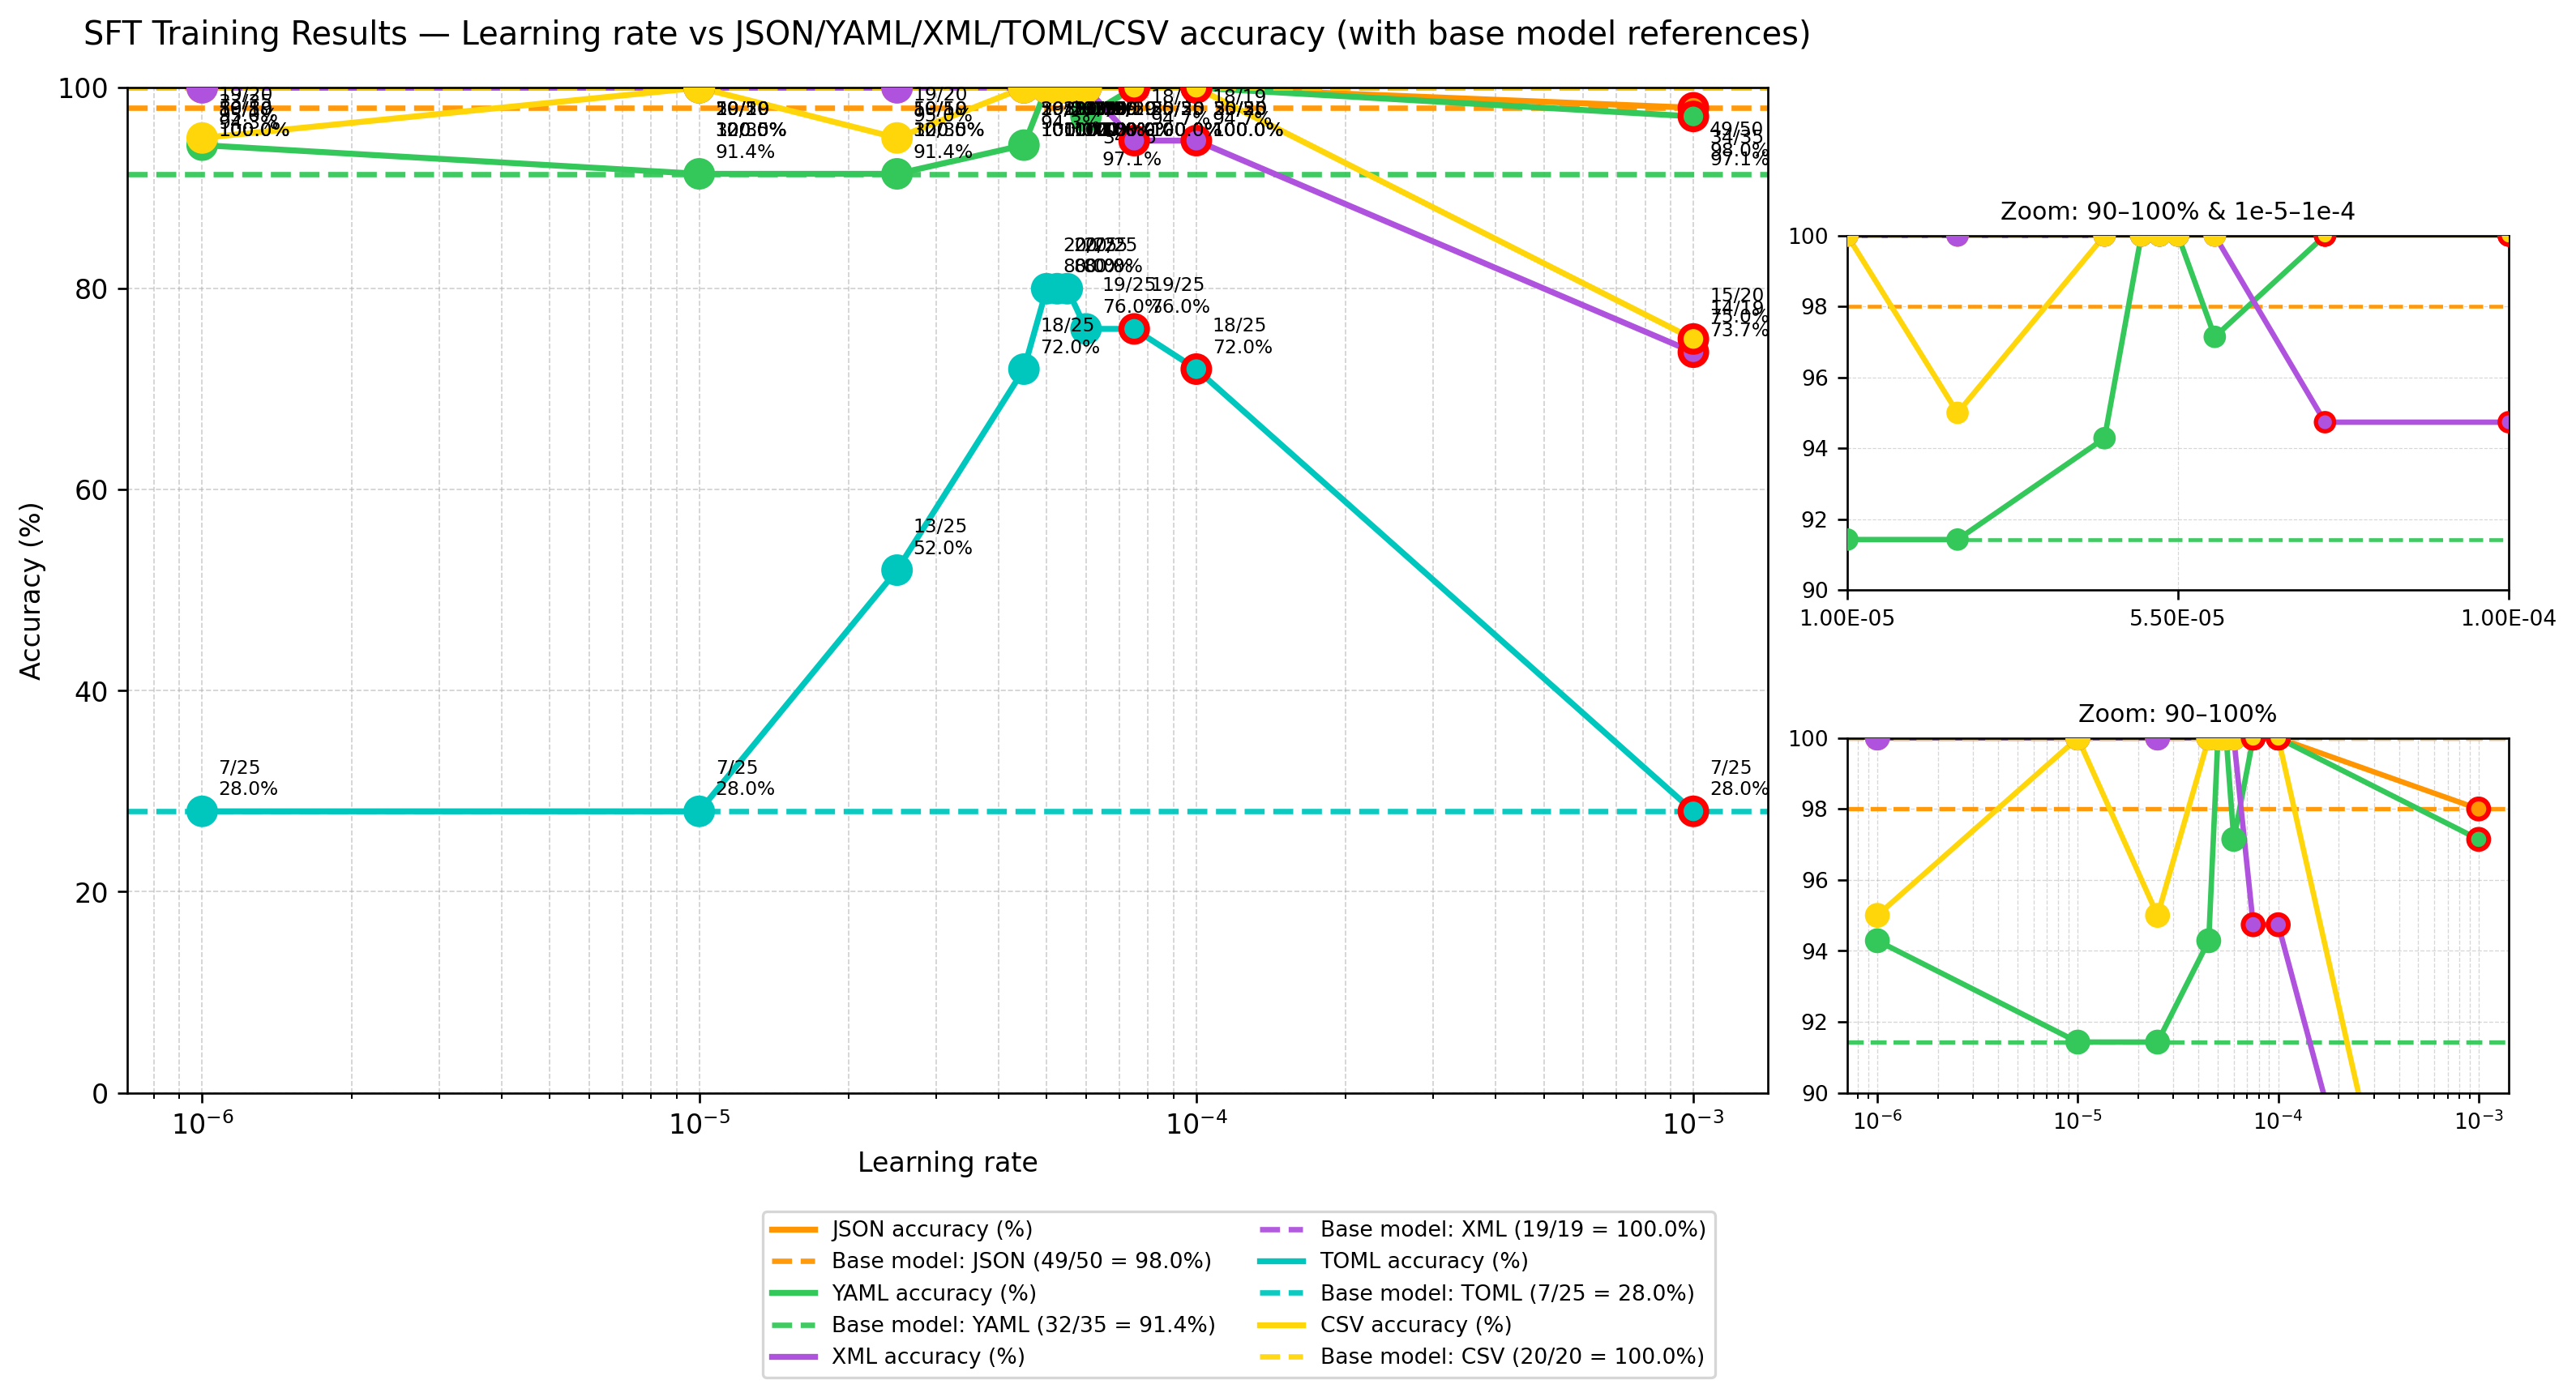

In [6]:
for p in [OUT_PNG_1, OUT_PNG_2]:
    if os.path.exists(p):
        display(Image(filename=p))
    else:
        print('Not found:', p)
